# 04 - Error Analysis

**Goal:** understand where the model fails.

Loads a trained checkpoint, runs inference on the validation split, and produces:
- a confusion matrix,
- the top-K worst classes (lowest per-class accuracy),
- a few hard examples (highest loss).

Depends on the model registry (Phase 3) and checkpoint IO (Phase 4).

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent
SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

sns.set_theme(style="whitegrid")

In [2]:
# TODO: once Phase 4 lands, import:
#   from smth2smth.shared.io.checkpoints import load_checkpoint
#   from smth2smth.shared.models.registry import build_model
# and replace the stub below.

CHECKPOINT_PATH = REPO_ROOT / "checkpoints" / "track_a" / "best_model.pt"
print(CHECKPOINT_PATH)
print("checkpoint exists:", CHECKPOINT_PATH.exists())

/Data/thomas.turkieh/project_modal_P3/checkpoints/track_a/best_model.pt
checkpoint exists: False


## Confusion matrix from CSV predictions

This cell first tries to use a CSV from `submissions/`.
If matching ground truth labels are available (same `video_name`s), it plots a confusion matrix.
If not, it falls back to plotting predicted class distribution and explains why confusion matrix is unavailable.

No ground-truth CSV provided: showing prediction distribution only.
Set GROUND_TRUTH_CSV to compute a confusion matrix from CSV files.


,video_name,predicted_class
0,video_1000,9
1,video_100051,6
2,video_100065,18
3,video_100078,30
4,video_100121,23


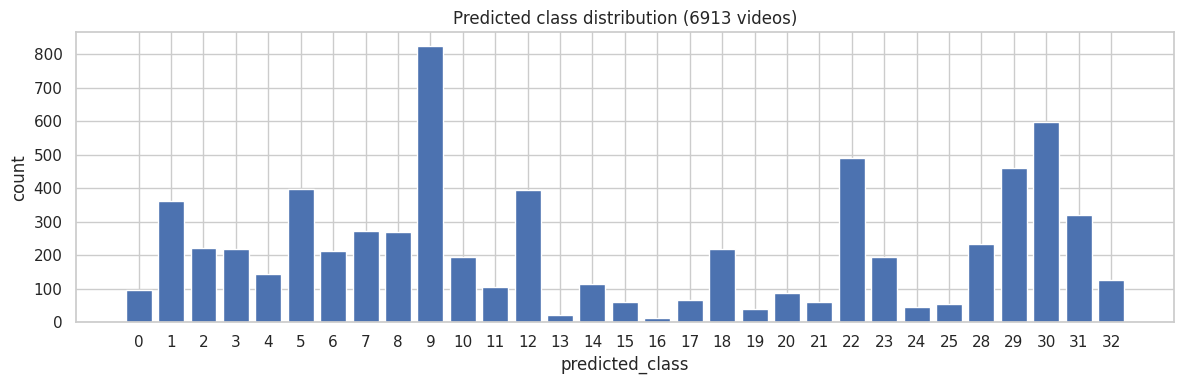

In [3]:
from collections import Counter

# Pick a predictions CSV (generated by your submit pipeline).
PREDICTIONS_CSV = REPO_ROOT / "submissions" / "track_a_newbest_20260509.csv"

# Optional: if you have a labeled CSV, set it here with columns: video_name,true_class
# Example: GROUND_TRUTH_CSV = REPO_ROOT / "data" / "val_labels.csv"
GROUND_TRUTH_CSV = None

if not PREDICTIONS_CSV.exists():
    raise FileNotFoundError(f"Predictions CSV not found: {PREDICTIONS_CSV}")

pred_df = pd.read_csv(PREDICTIONS_CSV)
required_cols = {"video_name", "predicted_class"}
if not required_cols.issubset(pred_df.columns):
    raise ValueError(f"{PREDICTIONS_CSV} must contain columns: {sorted(required_cols)}")

pred_df = pred_df[["video_name", "predicted_class"]].copy()
pred_df["predicted_class"] = pred_df["predicted_class"].astype(int)

# Path A: explicit GT CSV available -> true confusion matrix from CSV join.
if GROUND_TRUTH_CSV is not None:
    gt_df = pd.read_csv(GROUND_TRUTH_CSV)
    gt_required_cols = {"video_name", "true_class"}
    if not gt_required_cols.issubset(gt_df.columns):
        raise ValueError(f"{GROUND_TRUTH_CSV} must contain columns: {sorted(gt_required_cols)}")

    merged = pred_df.merge(gt_df[["video_name", "true_class"]], on="video_name", how="inner")
    if merged.empty:
        raise ValueError("No overlapping video_name rows between predictions and ground truth CSV.")

    y_true = merged["true_class"].to_numpy(dtype=int)
    y_pred = merged["predicted_class"].to_numpy(dtype=int)

    num_classes = int(max(y_true.max(), y_pred.max())) + 1
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, ax=ax, cbar=True, cmap="Blues")
    ax.set_title(f"Confusion matrix from CSV ({len(merged)} matched rows)")
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")
    plt.tight_layout()

    top1 = float((y_true == y_pred).mean())
    print(f"Matched rows: {len(merged)}")
    print(f"Top-1 accuracy: {top1:.4f}")

# Path B: no GT available -> still use submissions CSV for prediction diagnostics.
else:
    print("No ground-truth CSV provided: showing prediction distribution only.")
    print("Set GROUND_TRUTH_CSV to compute a confusion matrix from CSV files.")

    counts = Counter(pred_df["predicted_class"].tolist())
    series = pd.Series(counts).sort_index()

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(series.index.astype(str), series.values)
    ax.set_title(f"Predicted class distribution ({len(pred_df)} videos)")
    ax.set_xlabel("predicted_class")
    ax.set_ylabel("count")
    if len(series) > 25:
        ax.set_xticks(ax.get_xticks()[:: max(1, len(series) // 25)])
    plt.tight_layout()

    display(pred_df.head())